# Reaction time

Strict-insula electrodes, time-resolved Ridge: which **functional clusters** predict trial RT?

A window is valid if it is FWER-significant and OOF \(r>0\). The main figure has Delay, Go, and Response panels. A **hit** electrode has at least one cluster after Delay onset, before Go onset, or before Response onset. Tasks are pooled. Organization is by NMF cluster (sustain / motor / sensory), not AIC/PIC.

**HGA–RT encoding** (separate panel): for assigned pre-Go hits, within-subject fast vs slow HGA traces and subject-level mean-HGA vs \(\log\mathrm{RT}\) correlations. Prediction \(r\) is not the encoding sign.

Figures are inline. Set `SAVE_SVG=True` to write SVG under `img/reaction_time/`.


In [1]:
%matplotlib inline
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import RESULTS_ROOT, img_dir, save_svg

warnings.filterwarnings('ignore', category=FutureWarning)

cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.dpi'] = 120

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
gold = '#C4A35A'

cluster_order = ['sustain', 'motor', 'sensory']
cluster_colors = {
    'sustain': red,
    'motor': gold,
    'sensory': blue,
    'unassigned': '0.55',
}
cluster_labels = {
    'sustain': 'sustained / ramping',
    'motor': 'motor',
    'sensory': 'sensory / transient',
}
phase_order = ['Delay', 'Go', 'Response']
task_order = ['LexicalDelay', 'PhonemeSequence', 'PictureNaming']
task_short = {
    'LexicalDelay': 'LD',
    'PhonemeSequence': 'PS',
    'PictureNaming': 'PN',
}

export_dir = img_dir('reaction_time')
SAVE_SVG = True
print('ROOT:', ROOT)
print('SAVE_SVG =', SAVE_SVG)


ROOT: /hpc/group/coganlab/nanlinshi/insula-functional
SAVE_SVG = True


## 1. Load summaries


In [2]:
RT_ROOT = RESULTS_ROOT / 'rt'
SUMMARY_DIR = RT_ROOT / 'summaries'

# Time axis: show flanks around each locked event.
DELAY_XLIM = (-1.0, 1.5)
GO_XLIM = (-1.0, 1.5)
RESPONSE_XLIM = (-1.0, 1.5)
PHASE_XLIMS = {'Delay': DELAY_XLIM, 'Go': GO_XLIM, 'Response': RESPONSE_XLIM}


def _cluster_label(s):
    if pd.isna(s) or str(s).strip() == '':
        return 'unassigned'
    return str(s)


def in_hit_window(row):
    """Cluster overlaps after Delay, before Go, or before Response."""
    if row['phase'] == 'Delay':
        return float(row['end_time']) > 0
    if row['phase'] == 'Go':
        return float(row['start_time']) < 0
    if row['phase'] == 'Response':
        return float(row['start_time']) < 0
    return False


coverage = pd.read_csv(SUMMARY_DIR / 'coverage.csv')
electrodes = pd.read_csv(SUMMARY_DIR / 'electrodes.csv')
clusters = pd.read_csv(SUMMARY_DIR / 'significant_clusters.csv')

electrodes['functional_cluster'] = electrodes['functional_cluster'].map(_cluster_label)
clusters['functional_cluster'] = clusters['functional_cluster'].map(_cluster_label)
clusters['in_hit_window'] = clusters.apply(in_hit_window, axis=1)

hit_keys = (
    clusters.loc[clusters.in_hit_window, ['task', 'subject', 'channel']]
    .drop_duplicates()
)
hit_keys['hit'] = True

print(
    f'coverage={len(coverage)} | electrodes={len(electrodes)} | '
    f'clusters={len(clusters)} | delay-response hits (task × electrode)='
    f'{len(hit_keys)}'
)


coverage=300 | electrodes=2178 | clusters=319 | delay-response hits (task × electrode)=103


## 2. Coverage (table only)

Denominator = unique strict-insula electrodes that entered the model. Hits are Delay after onset, Go before onset, or Response before onset.


In [3]:
elec_unique = electrodes.drop_duplicates(['task', 'subject', 'channel'])
hit_task_elec = hit_keys.copy()
hit_unique = hit_keys.drop_duplicates(['subject', 'channel'])

cover_tbl = pd.DataFrame({
    'n_subjects': coverage.groupby('task')['subject'].nunique().reindex(task_order),
    'n_electrodes': elec_unique.groupby('task').size().reindex(task_order),
    'n_hit_task_electrodes': hit_task_elec.groupby('task').size().reindex(task_order).fillna(0).astype(int),
})
cover_tbl.loc['pooled'] = [
    coverage['subject'].nunique(),
    electrodes.drop_duplicates(['subject', 'channel']).shape[0],
    hit_unique.shape[0],
]
display(cover_tbl)

print('Hits by functional cluster (task × electrode / unique electrode)')
by_cl = pd.DataFrame({
    'task × electrode': (
        hit_keys.merge(
            clusters.drop_duplicates(['task', 'subject', 'channel'])[
                ['task', 'subject', 'channel', 'functional_cluster']
            ],
            on=['task', 'subject', 'channel'],
        )
        .groupby('functional_cluster')
        .size()
        .reindex(cluster_order + ['unassigned'])
        .fillna(0)
        .astype(int)
    ),
    'unique electrode': (
        hit_keys.merge(
            electrodes.drop_duplicates(['subject', 'channel'])[
                ['subject', 'channel', 'functional_cluster']
            ],
            on=['subject', 'channel'],
        )
        .drop_duplicates(['subject', 'channel'])
        .groupby('functional_cluster')
        .size()
        .reindex(cluster_order + ['unassigned'])
        .fillna(0)
        .astype(int)
    ),
})
display(by_cl)


,n_subjects,n_electrodes,n_hit_task_electrodes
task,,,
LexicalDelay,38,271,33
PhonemeSequence,35,236,14
PictureNaming,27,219,56
pooled,63,450,86


Hits by functional cluster (task × electrode / unique electrode)


,task × electrode,unique electrode
functional_cluster,,
sustain,20,17
motor,42,34
sensory,6,5
unassigned,35,30


## 3c. Combined: mean \(r(t)\) over cluster raster

Same electrodes and phases as §3 / §3b. Top: cluster-average OOF \(r\) in significant windows. Bottom: significance raster. Shared time axes; raster panel styling matches §3.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/reaction_time/rt_clusters_r_over_raster.svg


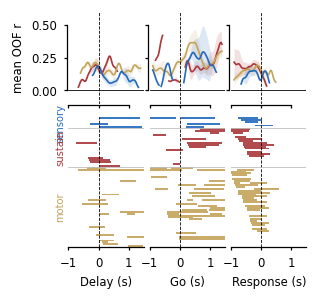

In [42]:
from matplotlib.gridspec import GridSpec

# Requires §3 (raster helpers + hit_keys/clusters) and §3b (r loaders/smoothers).
if 'raster_rows' not in dir() or raster_rows is None or len(raster_rows) == 0:
    _, raster_rows = plot_cluster_raster(clusters, hit_keys)
if 'r_traces' not in dir() or r_traces is None or len(r_traces) == 0:
    r_traces = load_raster_r(RT_ROOT, raster_rows)


def plot_r_over_raster(clusters_df, hit_keys_df, r_df, rows):
    """Stack mean OOF r(t) above the §3 significance raster (shared time axes)."""
    # Heatmap / curve stack order (top → bottom): sensory, sustain, motor.
    raster_cluster_order = ['sensory', 'sustain', 'motor']
    assigned = clusters_df[clusters_df.functional_cluster.isin(raster_cluster_order)].copy()
    hit_assigned = hit_keys_df.merge(
        assigned.drop_duplicates(['task', 'subject', 'channel'])[
            ['task', 'subject', 'channel', 'functional_cluster']
        ],
        on=['task', 'subject', 'channel'],
    )
    hit_assigned = hit_assigned[
        hit_assigned.functional_cluster.isin(raster_cluster_order)
    ]
    onset = (
        assigned.merge(
            hit_assigned[['task', 'subject', 'channel']],
            on=['task', 'subject', 'channel'],
        )
        .loc[lambda d: d.in_hit_window]
        .groupby(['task', 'subject', 'channel'], as_index=False)
        .agg(
            functional_cluster=('functional_cluster', 'first'),
            sort_time=('start_time', 'min'),
        )
    )
    onset['cluster_rank'] = onset['functional_cluster'].map(
        {name: i for i, name in enumerate(raster_cluster_order)}
    )
    rows = (
        onset.sort_values(['cluster_rank', 'sort_time', 'task', 'channel'])
        .reset_index(drop=True)
        .assign(y=lambda d: np.arange(len(d)))
    )
    plot_cl = assigned.merge(
        rows[['task', 'subject', 'channel', 'y']],
        on=['task', 'subject', 'channel'],
    )
    n = len(rows)
    n_by_cl = rows.groupby('functional_cluster').size()
    n_phase = len(phase_order)
    xlims = PHASE_XLIMS

    # Raster geometry from §3; top row is a compact r panel.
    width = 2 * n_phase * cm
    raster_h = max(2.0, 0.05 * n) * cm
    r_h = 2.4 * cm
    fig = plt.figure(figsize=(width, r_h + raster_h))
    gs = GridSpec(
        2,
        n_phase,
        figure=fig,
        height_ratios=[r_h, raster_h],
        hspace=0.12,
        wspace=0.08,
    )

    axes_r = [fig.add_subplot(gs[0, 0])]
    axes_r += [
        fig.add_subplot(gs[0, i], sharex=None, sharey=axes_r[0])
        for i in range(1, n_phase)
    ]
    axes_h = [
        fig.add_subplot(gs[1, i], sharex=axes_r[i]) for i in range(n_phase)
    ]

    # --- Top: mean r(t); y ticks/label only on the first axis ---
    for ax, phase in zip(axes_r, phase_order):
        sub = r_df[r_df.phase == phase]
        for cl in cluster_order:
            csub = sub[sub.functional_cluster == cl]
            if csub.empty:
                continue
            grouped = csub.groupby('time')['r']
            mean = grouped.mean()
            sem = grouped.sem().fillna(0.0)
            y = _smooth_segments(mean.to_numpy(), smooth_sigma)
            e = _smooth_segments(sem.to_numpy(), smooth_sigma)
            e = np.where(np.isfinite(y), np.nan_to_num(e, nan=0.0), np.nan)
            ax.plot(
                mean.index,
                y,
                color=cluster_colors[cl],
                lw=1,
                label=f'{cluster_labels[cl]} (n={int(n_by_cl.get(cl, 0))})',
            )
            ax.fill_between(
                mean.index,
                y - e,
                y + e,
                color=cluster_colors[cl],
                alpha=0.15,
                linewidth=0,
            )
        ax.axhline(0, color='k', linewidth=0.5)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
        ax.set_xlim(*xlims[phase])
        ax.set_ylim(-0.1, 0.6)
        ax.set_xticks([-1, 0, 1])
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=1, trim=True)
        ax.tick_params(labelbottom=False)

    axes_r[0].set_ylabel('mean OOF r', fontsize=fontsize)
    for ax in axes_r[1:]:
        ax.tick_params(labelleft=False)
        ax.set_ylabel('')

    # --- Bottom: significance raster (same drawing as §3) ---
    for ax, phase in zip(axes_h, phase_order):
        xlim = xlims[phase]
        times, mask = _sig_matrix(plot_cl, n, phase, xlim)
        t_edges = np.concatenate([times, [times[-1] + DT]])
        y_edges = np.arange(n + 1) - 0.5
        ax.pcolormesh(
            t_edges,
            y_edges,
            _rgba_mask(mask, rows['functional_cluster'].to_numpy()),
            shading='auto',
            rasterized=True,
        )
        ax.set_xlim(*xlim)
        ax.set_xticks([-1, 0, 1])
        ax.set_ylim(n - 0.5, -0.5)
        ax.set_xlabel(f'{phase} (s)', fontsize=fontsize)
        _style_rt_ax(ax)
        ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')

    for cl in raster_cluster_order:
        ys = rows.loc[rows.functional_cluster == cl, 'y']
        if ys.empty:
            continue
        y0, y1 = ys.min() - 0.5, ys.max() + 0.5
        for ax in axes_h:
            ax.axhline(y1, color='0.75', linewidth=0.5)
        axes_h[0].text(
            -0.04,
            0.5 * (y0 + y1),
            cl,
            transform=axes_h[0].get_yaxis_transform(),
            fontsize=fontsize - 1,
            color=cluster_colors[cl],
            va='center',
            ha='right',
            rotation=90,
            clip_on=False,
        )

    fig.subplots_adjust(left=0.14, right=0.98, top=0.96, bottom=0.10, wspace=0.08, hspace=0.12)
    return fig

fig = plot_r_over_raster(clusters, hit_keys, r_traces, raster_rows)
if SAVE_SVG:
    save_svg(fig, export_dir / 'rt_clusters_r_over_raster')
print('Wrote', export_dir / 'rt_clusters_r_over_raster.svg')
plt.show()


## 4. Spatial (all tasks pooled)

Same insula zoom as the other brain figures: `cvs_avg35_inMNI152` pial, superior view, electrodes projected to the surface. Gray = modeled electrodes without a hit; color = functional cluster for hits. Hits are the same set as the raster: Delay after onset, Go before onset, or Response before onset. Electrodes whose only significant clusters start after Response onset are not hits.


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-08-18 12:56:58.532 (10726.592s) [    7FE98D243740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xee5c470): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

functional_cluster
sustain       17
motor         34
sensory        5
unassigned    30
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/reaction_time/rt_spatial_insula.svg


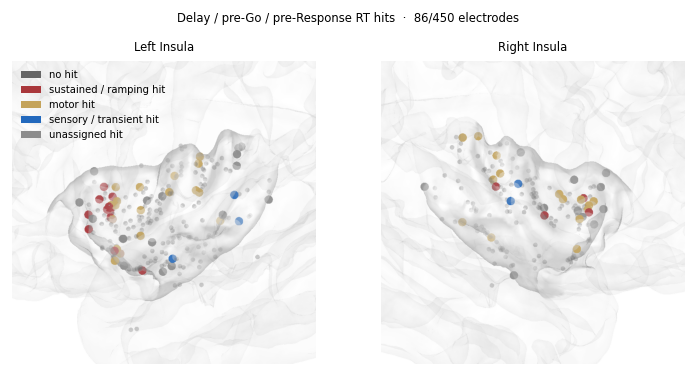

In [44]:
import mne

from src.decoding.viz_insula_patterns import render_insula_hemisphere_categorical
from src.univariate.viz_mean import BrainSurfaceContext

mne.viz.set_3d_backend('notebook')

spatial = electrodes.drop_duplicates(['subject', 'channel']).copy()
hit_unique = hit_keys.drop_duplicates(['subject', 'channel'])[['subject', 'channel']].assign(hit=True)
spatial = spatial.merge(hit_unique, on=['subject', 'channel'], how='left')
spatial['hit'] = spatial['hit'].fillna(False)
spatial['x'] = spatial['x_template']
spatial['y'] = spatial['y_template']
spatial['z'] = spatial['z_template']
spatial = spatial.dropna(subset=['x', 'y', 'z'])
spatial['significant'] = spatial['hit'].astype(bool)
spatial['color'] = spatial['functional_cluster'].map(cluster_colors).fillna('0.55')

brain_ctx = BrainSurfaceContext()
fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
for ax, hemi, title in zip(axes, ('lh', 'rh'), ('Left Insula', 'Right Insula')):
    img = render_insula_hemisphere_categorical(
        spatial, hemi, brain_ctx,
        sig_size=22,
        nsig_opacity=0.35,
    )
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=fontsize)

axes[0].legend(
    handles=[
        Patch(facecolor='0.4', label='no hit'),
        *[
            Patch(facecolor=cluster_colors[cl], label=f'{cluster_labels.get(cl, cl)} hit')
            for cl in cluster_order + ['unassigned']
            if (spatial.hit & (spatial.functional_cluster == cl)).any()
        ],
    ],
    loc='upper left',
    fontsize=fontsize - 1,
    frameon=False,
)
fig.suptitle(
    f'Delay / pre-Go / pre-Response RT hits  ·  {int(spatial.hit.sum())}/{len(spatial)} electrodes',
    fontsize=fontsize,
)
fig.tight_layout()
if SAVE_SVG:
    save_svg(fig, export_dir / 'rt_spatial_insula')

print(
    spatial.loc[spatial.hit, 'functional_cluster']
    .value_counts()
    .reindex(cluster_order + ['unassigned'])
    .fillna(0)
    .astype(int)
    .to_string()
)

print("Wrote", export_dir / "rt_spatial_insula.svg")
plt.show()


## 5. HGA–RT encoding (Go, assigned pre-Go hits)

Go-aligned only. Assigned NMF electrodes with a valid cluster starting before Go. Top: within-subject median-split HGA (fast vs slow RT), grand mean ± SEM. Bottom: subject-level Pearson \(r\)(window-mean HGA, \(\log\mathrm{RT}\)); negative means higher HGA with shorter RT. Primary test = Wilcoxon on subject \(r\); LMM is printed as a supplement.

Requires `results/rt/summaries/hga_rt_*.csv` from `python -m src.reaction_time.summarize_insula_rt_encoding` (also run by the viz Slurm job).


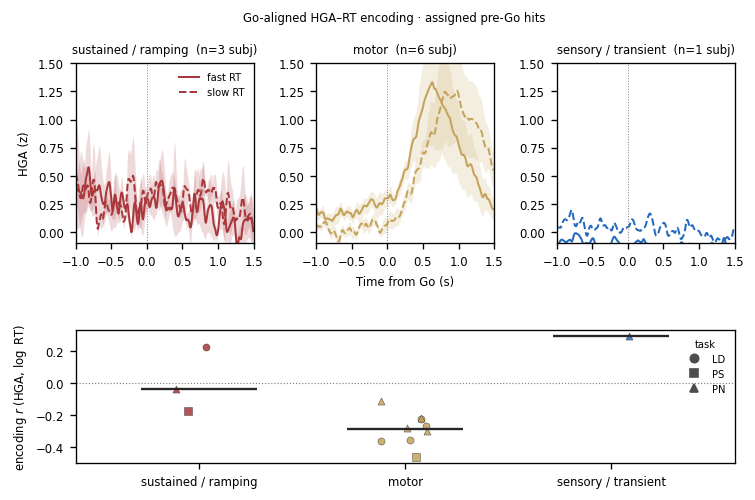

inference (Wilcoxon primary; LMM supplement)


,test,scope_type,scope,n_subjects,n_negative_subjects,median_subject_r,statistic,p_descriptive,coef,ci_low,ci_high,inference_note,formula,n_trials
0,wilcoxon,all_clusters,all,10,8.0,-0.213680,12.000000,6.542969e-02,-0.213680,NaN,NaN,post-selection descriptive; not independent co...,NaN,NaN
1,wilcoxon,functional_cluster,sustain,3,2.0,-0.037087,3.000000,6.250000e-01,-0.037087,NaN,NaN,post-selection descriptive; not independent co...,NaN,NaN
2,wilcoxon,functional_cluster,motor,6,6.0,-0.285789,0.000000,1.562500e-02,-0.285789,NaN,NaN,post-selection descriptive; not independent co...,NaN,NaN
3,wilcoxon,functional_cluster,sensory,1,0.0,0.295031,NaN,NaN,0.295031,NaN,NaN,post-selection descriptive; not independent co...,NaN,NaN
4,lmm,all_clusters,all,10,NaN,NaN,-8.275254,1.281826e-16,-0.076365,-0.094452,-0.058278,post-selection descriptive; not independent co...,rt_log ~ hga_z,2141.0
5,lmm,all_clusters,all_task_covariate,10,NaN,NaN,-8.403587,4.330443e-17,-0.076365,-0.094176,-0.058554,post-selection descriptive; not independent co...,rt_log ~ hga_z + C(task),2141.0
6,lmm,functional_cluster,sustain,3,NaN,NaN,1.371668,1.701668e-01,0.020295,-0.008705,0.049295,post-selection descriptive; not independent co...,rt_log ~ hga_z,421.0
7,lmm,functional_cluster,motor,6,NaN,NaN,-11.217381,3.350469e-29,-0.135238,-0.158868,-0.111608,post-selection descriptive; not independent co...,rt_log ~ hga_z,1507.0
8,lmm,functional_cluster,sensory,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,post-selection descriptive; not independent co...,rt_log ~ hga_z,213.0


subject × cluster rows: 13 | unique subjects: 10


In [ ]:
from matplotlib.lines import Line2D

encoding_files = {
    'traces': SUMMARY_DIR / 'hga_rt_go_traces.csv',
    'subjects': SUMMARY_DIR / 'hga_rt_encoding_subjects.csv',
    'inference': SUMMARY_DIR / 'hga_rt_inference.csv',
}
missing = [name for name, path in encoding_files.items() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        'Missing HGA–RT encoding CSVs: '
        + ', '.join(missing)
        + '. Run: python -m src.reaction_time.summarize_insula_rt_encoding'
    )

traces = pd.read_csv(encoding_files['traces'])
subjects_enc = pd.read_csv(encoding_files['subjects'])
inference = pd.read_csv(encoding_files['inference'])

task_markers = {
    'LexicalDelay': 'o',
    'PhonemeSequence': 's',
    'PictureNaming': '^',
}

fig = plt.figure(figsize=(18 * cm, 11 * cm))
gs = fig.add_gridspec(2, 3, height_ratios=[1.35, 1.0], hspace=0.55, wspace=0.35)

for col, cluster in enumerate(cluster_order):
    ax = fig.add_subplot(gs[0, col])
    sub = traces.loc[traces.functional_cluster == cluster]
    color = cluster_colors[cluster]
    if sub.empty:
        ax.set_title(cluster_labels[cluster], fontsize=fontsize)
        ax.set_xlim(*GO_XLIM)
        continue
    # Grand mean across task × subject traces.
    by_time = (
        sub.groupby('time', sort=True)
        .agg(
            hga_fast=('hga_fast', 'mean'),
            hga_slow=('hga_slow', 'mean'),
            sem_fast=('hga_fast', 'sem'),
            sem_slow=('hga_slow', 'sem'),
            n=('subject', 'nunique'),
        )
        .reset_index()
    )
    t = by_time['time'].to_numpy(dtype=float)
    for key, sem_key, ls, label in (
        ('hga_fast', 'sem_fast', '-', 'fast RT'),
        ('hga_slow', 'sem_slow', '--', 'slow RT'),
    ):
        y = by_time[key].to_numpy(dtype=float)
        se = by_time[sem_key].fillna(0).to_numpy(dtype=float)
        ax.plot(t, y, color=color, lw=1.2, ls=ls, label=label)
        ax.fill_between(t, y - se, y + se, color=color, alpha=0.18, linewidth=0)
    ax.axvline(0, color='0.5', lw=0.6, ls=':')
    ax.set_xlim(*GO_XLIM)
    ax.set_ylim(-0.1, 1.5)
    ax.set_title(
        f"{cluster_labels[cluster]}  (n={int(by_time['n'].iloc[0])} subj)",
        fontsize=fontsize,
    )
    ax.tick_params(labelsize=fontsize)
    if col == 0:
        ax.set_ylabel('HGA (z)', fontsize=fontsize)
        ax.legend(fontsize=fontsize - 1, frameon=False, loc='upper right')
    if col == 1:
        ax.set_xlabel('Time from Go (s)', fontsize=fontsize)

ax_r = fig.add_subplot(gs[1, :])
rng = np.random.default_rng(0)
for col, cluster in enumerate(cluster_order):
    frame = subjects_enc.loc[subjects_enc.functional_cluster == cluster].copy()
    if frame.empty:
        continue
    x0 = col
    for task, marker in task_markers.items():
        pts = frame.loc[frame.task == task, 'mean_hga_log_rt_r'].to_numpy(dtype=float)
        pts = pts[np.isfinite(pts)]
        if pts.size == 0:
            continue
        jitter = rng.uniform(-0.12, 0.12, size=pts.size)
        ax_r.scatter(
            np.full(pts.size, x0) + jitter,
            pts,
            s=18,
            c=cluster_colors[cluster],
            marker=marker,
            alpha=0.85,
            linewidths=0.3,
            edgecolors='0.2',
            zorder=3,
        )
    # Subject-collapsed median (across tasks) for the strip center line.
    subj_med = (
        frame.groupby('subject')['mean_hga_log_rt_r'].median().to_numpy(dtype=float)
    )
    subj_med = subj_med[np.isfinite(subj_med)]
    if subj_med.size:
        ax_r.hlines(
            np.median(subj_med),
            x0 - 0.28,
            x0 + 0.28,
            colors='0.15',
            lw=1.4,
            zorder=4,
        )

ax_r.axhline(0, color='0.5', lw=0.7, ls=':')
ax_r.set_xticks(range(len(cluster_order)))
ax_r.set_xticklabels([cluster_labels[c] for c in cluster_order], fontsize=fontsize)
ax_r.set_ylabel(r'encoding $r$ (HGA, $\log$ RT)', fontsize=fontsize)
ax_r.set_xlim(-0.6, len(cluster_order) - 0.4)
ax_r.tick_params(labelsize=fontsize)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        color='0.3',
        linestyle='None',
        markersize=5,
        label=task_short[task],
    )
    for task, marker in task_markers.items()
]
ax_r.legend(
    handles=legend_handles,
    fontsize=fontsize - 1,
    frameon=False,
    loc='upper right',
    title='task',
    title_fontsize=fontsize - 1,
)

fig.suptitle(
    'Go-aligned HGA–RT encoding · assigned pre-Go hits',
    fontsize=fontsize,
    y=0.98,
)
if SAVE_SVG:
    save_svg(fig, export_dir / 'rt_hga_rt_go')
plt.show()

print('inference (Wilcoxon primary; LMM supplement)')
display(inference)
print(
    'subject × cluster rows:',
    len(subjects_enc),
    '| unique subjects:',
    subjects_enc.subject.nunique() if len(subjects_enc) else 0,
)

## 5a. Motor focus (three panels)

1. Go-aligned fast/slow HGA for **motor** assigned pre-Go hits.
2. Encoding $r$: one point per task × subject (same marker; tasks not collapsed).
3. Trial scatter for the strongest negative encoding unit (most negative $r$).


median r=-0.283 | Wilcoxon p=0.01562 | example=D0061/PhonemeSequence r=-0.465


,task,subject,mean_hga_log_rt_r,n_trials
5,PhonemeSequence,D0061,-0.464938,79
1,LexicalDelay,D0054,-0.366035,123
4,LexicalDelay,D0090,-0.354930,139
9,PictureNaming,D0084,-0.298897,222
7,PictureNaming,D0079,-0.282696,182
3,LexicalDelay,D0084,-0.270604,146
2,LexicalDelay,D0079,-0.222780,156
11,PictureNaming,D0090,-0.218727,226
12,PictureNaming,D0119,-0.114702,234


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/reaction_time/rt_hga_rt_motor.svg


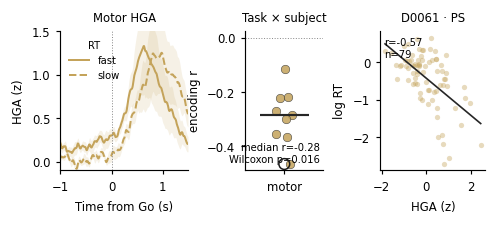

In [57]:
from scipy.stats import pearsonr, wilcoxon

if 'traces' not in dir() or 'subjects_enc' not in dir():
    traces = pd.read_csv(SUMMARY_DIR / 'hga_rt_go_traces.csv')
    subjects_enc = pd.read_csv(SUMMARY_DIR / 'hga_rt_encoding_subjects.csv')

trials_path = SUMMARY_DIR / 'hga_rt_trials.csv'
if not trials_path.is_file():
    raise FileNotFoundError(
        f'Missing {trials_path.name}. '
        'Run: python -m src.reaction_time.summarize_insula_rt_encoding'
    )
trials = pd.read_csv(trials_path)

motor_traces = traces.loc[traces.functional_cluster == 'motor'].copy()
motor_enc = subjects_enc.loc[subjects_enc.functional_cluster == 'motor'].copy()
motor_trials = trials.loc[trials.functional_cluster == 'motor'].copy()
motor_color = cluster_colors['motor']
motor_elec = pd.read_csv(SUMMARY_DIR / 'hga_rt_encoding_electrodes.csv')
motor_elec = motor_elec.loc[motor_elec.functional_cluster == 'motor']
n_motor_elec = int(motor_elec.drop_duplicates(['subject', 'channel']).shape[0])

# Typical example: task × subject with the strongest negative encoding r.
typical = motor_enc.loc[motor_enc['mean_hga_log_rt_r'].idxmin()]
typical_task = str(typical['task'])
typical_subject = str(typical['subject'])
typical_r = float(typical['mean_hga_log_rt_r'])
group_med = float(motor_enc['mean_hga_log_rt_r'].median())

# Subject-level Wilcoxon (primary), matching inference CSV.
subj_r = (
    motor_enc.groupby('subject')['mean_hga_log_rt_r'].median().to_numpy(dtype=float)
)
subj_r = subj_r[np.isfinite(subj_r)]
n_neg_subj = int((subj_r < 0).sum())
if len(subj_r) >= 2 and not np.allclose(subj_r, 0.0):
    wilcoxon_p = float(wilcoxon(subj_r, alternative='less').pvalue)
else:
    wilcoxon_p = np.nan

fig, axes = plt.subplots(
    1,
    3,
    figsize=(10 * cm, 4.2 * cm),
    gridspec_kw=dict(width_ratios=[1.4, 0.85, 1.15], wspace=0.55),
)
ax_l, ax_m, ax_r = axes

def _style(ax):
    ax.tick_params(labelsize=fontsize, width=0.7, length=2.5)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

# --- 1. Go-aligned motor HGA ---
by_time = (
    motor_traces.groupby('time', sort=True)
    .agg(
        hga_fast=('hga_fast', 'mean'),
        hga_slow=('hga_slow', 'mean'),
        sem_fast=('hga_fast', 'sem'),
        sem_slow=('hga_slow', 'sem'),
    )
    .reset_index()
)
t = by_time['time'].to_numpy(dtype=float)
for key, sem_key, ls, label in (
    ('hga_fast', 'sem_fast', '-', 'fast'),
    ('hga_slow', 'sem_slow', '--', 'slow'),
):
    y = by_time[key].to_numpy(dtype=float)
    se = by_time[sem_key].fillna(0).to_numpy(dtype=float)
    ax_l.plot(t, y, color=motor_color, lw=1.2, ls=ls, label=label)
    ax_l.fill_between(t, y - se, y + se, color=motor_color, alpha=0.15, linewidth=0)
ax_l.axvline(0, color='0.55', lw=0.6, ls=':')
ax_l.set_xlim(*GO_XLIM)
ax_l.set_ylim(-0.1, 1.5)
ax_l.set_xlabel('Time from Go (s)', fontsize=fontsize)
ax_l.set_ylabel('HGA (z)', fontsize=fontsize)
ax_l.set_title(f'Motor HGA', fontsize=fontsize)
ax_l.legend(fontsize=fontsize - 1, frameon=False, loc='upper left', title='RT', title_fontsize=fontsize - 1)
_style(ax_l)

# --- 2. Encoding r strip: one point per task × subject, same marker ---
rng = np.random.default_rng(0)
vals = motor_enc['mean_hga_log_rt_r'].to_numpy(dtype=float)
vals = vals[np.isfinite(vals)]
jitter = rng.uniform(-0.08, 0.08, size=vals.size)
ax_m.scatter(
    jitter,
    vals,
    s=26,
    c=motor_color,
    marker='o',
    alpha=0.85,
    linewidths=0.35,
    edgecolors='0.2',
    zorder=3,
)
# Mark the typical example used in panel 3.
ax_m.scatter(
    [0.0],
    [typical_r],
    s=42,
    facecolors='none',
    edgecolors='0.1',
    linewidths=0.9,
    marker='o',
    zorder=5,
)
ax_m.axhline(0, color='0.55', lw=0.6, ls=':')
ax_m.hlines(group_med, -0.22, 0.22, colors='0.15', lw=1.3, zorder=4)
ax_m.set_xlim(-0.35, 0.35)
ax_m.set_xticks([0])
ax_m.set_xticklabels(['motor'], fontsize=fontsize)
ax_m.set_ylabel('encoding r', fontsize=fontsize)
ax_m.set_title('Task × subject', fontsize=fontsize)
_style(ax_m)
p_txt = f'{wilcoxon_p:.3f}' if np.isfinite(wilcoxon_p) else 'n/a'
ax_m.text(
    0.96,
    0.04,
    f'median r={group_med:.2f}\n'
    f'Wilcoxon p={p_txt}',
    transform=ax_m.transAxes,
    ha='right',
    va='bottom',
    fontsize=fontsize - 1,
    linespacing=1.35,
)

# --- 3. Typical trial scatter ---
ex = motor_trials.loc[
    (motor_trials.subject == typical_subject) & (motor_trials.task == typical_task)
].copy()
keep = np.isfinite(ex['hga_z']) & np.isfinite(ex['rt_log'])
ex = ex.loc[keep]
x = ex['hga_z'].to_numpy(dtype=float)
y = ex['rt_log'].to_numpy(dtype=float)
ax_r.scatter(
    x,
    y,
    s=10,
    c=motor_color,
    marker='o',
    alpha=0.4,
    linewidths=0,
    zorder=2,
)
if len(ex) >= 3 and np.std(x) > 0 and np.std(y) > 0:
    r_val, p_ex = pearsonr(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 50)
    ax_r.plot(x_line, slope * x_line + intercept, color='0.15', lw=1.0, zorder=3)
else:
    r_val = typical_r
    p_ex = np.nan
ax_r.set_xlabel('HGA (z)', fontsize=fontsize)
ax_r.set_ylabel('log RT', fontsize=fontsize)
ax_r.set_title(
    f'{typical_subject} · {task_short[typical_task]}',
    fontsize=fontsize,
)
_style(ax_r)
ax_r.text(
    0.04,
    0.96,
    f'r={r_val:.2f}\nn={len(ex)}',
    transform=ax_r.transAxes,
    ha='left',
    va='top',
    fontsize=fontsize - 1,
    linespacing=1.35,
)

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.18, top=0.88, wspace=0.55)
if SAVE_SVG:
    save_svg(fig, export_dir / 'rt_hga_rt_motor')

print(
    f"median r={group_med:.3f} | "
    f"Wilcoxon p={wilcoxon_p:.4g} | "
    f"example={typical_subject}/{typical_task} r={typical_r:.3f}"
)
display(
    motor_enc[['task', 'subject', 'mean_hga_log_rt_r', 'n_trials']].sort_values(
        'mean_hga_log_rt_r'
    )
)
print('Wrote', export_dir / 'rt_hga_rt_motor.svg')

## 5b. Sustain / sensory (same three-panel layout as 5a)

Same panels as motor, for the other two NMF components with assigned pre-Go hits:

1. Go-aligned fast/slow HGA  
2. Encoding \(r\): one point per task × subject  
3. Trial scatter for the most negative encoding unit  

Writes `rt_hga_rt_sustain.svg` and `rt_hga_rt_sensory.svg`.


sustain: median r=-0.037 | Wilcoxon p=0.625 | n_elec=3 | example=D0094/PhonemeSequence r=-0.175


,task,subject,mean_hga_log_rt_r,n_trials
6,PhonemeSequence,D0094,-0.174621,25
8,PictureNaming,D0080,-0.037087,238
0,LexicalDelay,D0053,0.223041,158


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/reaction_time/rt_hga_rt_sustain.svg
sensory: median r=0.295 | Wilcoxon p=nan | n_elec=1 | example=D0085/PictureNaming r=0.295


,task,subject,mean_hga_log_rt_r,n_trials
10,PictureNaming,D0085,0.295031,213


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/reaction_time/rt_hga_rt_sensory.svg


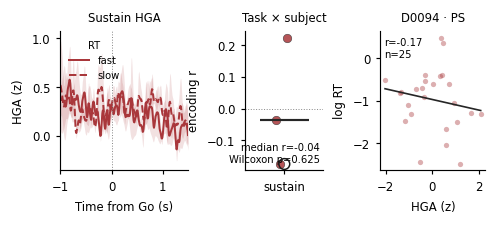

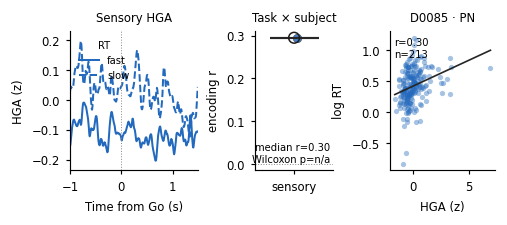

In [56]:
from scipy.stats import pearsonr, wilcoxon

if 'traces' not in dir() or 'subjects_enc' not in dir():
    traces = pd.read_csv(SUMMARY_DIR / 'hga_rt_go_traces.csv')
    subjects_enc = pd.read_csv(SUMMARY_DIR / 'hga_rt_encoding_subjects.csv')

trials_path = SUMMARY_DIR / 'hga_rt_trials.csv'
if not trials_path.is_file():
    raise FileNotFoundError(
        f'Missing {trials_path.name}. '
        'Run: python -m src.reaction_time.summarize_insula_rt_encoding'
    )
if 'trials' not in dir():
    trials = pd.read_csv(trials_path)

elec_enc = pd.read_csv(SUMMARY_DIR / 'hga_rt_encoding_electrodes.csv')


def _style_panel(ax):
    ax.tick_params(labelsize=fontsize, width=0.7, length=2.5)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)


def plot_cluster_hga_rt(cluster: str):
    """Three-panel HGA–RT encoding figure matching §5a motor layout."""
    cl_traces = traces.loc[traces.functional_cluster == cluster].copy()
    cl_enc = subjects_enc.loc[subjects_enc.functional_cluster == cluster].copy()
    cl_trials = trials.loc[trials.functional_cluster == cluster].copy()
    cl_elec = elec_enc.loc[elec_enc.functional_cluster == cluster]
    if cl_enc.empty or cl_traces.empty:
        print(f'skip {cluster}: no assigned pre-Go encoding rows')
        return None

    color = cluster_colors[cluster]
    n_elec = int(cl_elec.drop_duplicates(['subject', 'channel']).shape[0])
    title_cluster = cluster.capitalize()

    typical = cl_enc.loc[cl_enc['mean_hga_log_rt_r'].idxmin()]
    typical_task = str(typical['task'])
    typical_subject = str(typical['subject'])
    typical_r = float(typical['mean_hga_log_rt_r'])
    group_med = float(cl_enc['mean_hga_log_rt_r'].median())

    subj_r = (
        cl_enc.groupby('subject')['mean_hga_log_rt_r'].median().to_numpy(dtype=float)
    )
    subj_r = subj_r[np.isfinite(subj_r)]
    if len(subj_r) >= 2 and not np.allclose(subj_r, 0.0):
        wilcoxon_p = float(wilcoxon(subj_r, alternative='less').pvalue)
    else:
        wilcoxon_p = np.nan

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(10 * cm, 4.2 * cm),
        gridspec_kw=dict(width_ratios=[1.4, 0.85, 1.15], wspace=0.55),
    )
    ax_l, ax_m, ax_r = axes

    by_time = (
        cl_traces.groupby('time', sort=True)
        .agg(
            hga_fast=('hga_fast', 'mean'),
            hga_slow=('hga_slow', 'mean'),
            sem_fast=('hga_fast', 'sem'),
            sem_slow=('hga_slow', 'sem'),
        )
        .reset_index()
    )
    t = by_time['time'].to_numpy(dtype=float)
    y_lo, y_hi = [], []
    for key, sem_key, ls, label in (
        ('hga_fast', 'sem_fast', '-', 'fast'),
        ('hga_slow', 'sem_slow', '--', 'slow'),
    ):
        y = by_time[key].to_numpy(dtype=float)
        se = by_time[sem_key].fillna(0).to_numpy(dtype=float)
        ax_l.plot(t, y, color=color, lw=1.2, ls=ls, label=label)
        ax_l.fill_between(t, y - se, y + se, color=color, alpha=0.15, linewidth=0)
        y_lo.append(y - se)
        y_hi.append(y + se)
    ax_l.axvline(0, color='0.55', lw=0.6, ls=':')
    ax_l.set_xlim(*GO_XLIM)
    lo = float(np.nanmin(np.concatenate(y_lo)))
    hi = float(np.nanmax(np.concatenate(y_hi)))
    pad = 0.08 * max(hi - lo, 0.2)
    ax_l.set_ylim(lo - pad, hi + pad)
    ax_l.set_xlabel('Time from Go (s)', fontsize=fontsize)
    ax_l.set_ylabel('HGA (z)', fontsize=fontsize)
    ax_l.set_title(f'{title_cluster} HGA', fontsize=fontsize)
    ax_l.legend(
        fontsize=fontsize - 1,
        frameon=False,
        loc='upper left',
        title='RT',
        title_fontsize=fontsize - 1,
    )
    _style_panel(ax_l)

    rng = np.random.default_rng(0)
    vals = cl_enc['mean_hga_log_rt_r'].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    jitter = rng.uniform(-0.08, 0.08, size=vals.size)
    ax_m.scatter(
        jitter,
        vals,
        s=26,
        c=color,
        marker='o',
        alpha=0.85,
        linewidths=0.35,
        edgecolors='0.2',
        zorder=3,
    )
    ax_m.scatter(
        [0.0],
        [typical_r],
        s=42,
        facecolors='none',
        edgecolors='0.1',
        linewidths=0.9,
        marker='o',
        zorder=5,
    )
    ax_m.axhline(0, color='0.55', lw=0.6, ls=':')
    ax_m.hlines(group_med, -0.22, 0.22, colors='0.15', lw=1.3, zorder=4)
    ax_m.set_xlim(-0.35, 0.35)
    ax_m.set_xticks([0])
    ax_m.set_xticklabels([cluster], fontsize=fontsize)
    ax_m.set_ylabel('encoding r', fontsize=fontsize)
    ax_m.set_title('Task × subject', fontsize=fontsize)
    _style_panel(ax_m)
    p_txt = f'{wilcoxon_p:.3f}' if np.isfinite(wilcoxon_p) else 'n/a'
    ax_m.text(
        0.96,
        0.04,
        f'median r={group_med:.2f}\n'
        f'Wilcoxon p={p_txt}',
        transform=ax_m.transAxes,
        ha='right',
        va='bottom',
        fontsize=fontsize - 1,
        linespacing=1.35,
    )

    ex = cl_trials.loc[
        (cl_trials.subject == typical_subject) & (cl_trials.task == typical_task)
    ].copy()
    keep = np.isfinite(ex['hga_z']) & np.isfinite(ex['rt_log'])
    ex = ex.loc[keep]
    x = ex['hga_z'].to_numpy(dtype=float)
    y = ex['rt_log'].to_numpy(dtype=float)
    ax_r.scatter(
        x,
        y,
        s=10,
        c=color,
        marker='o',
        alpha=0.4,
        linewidths=0,
        zorder=2,
    )
    if len(ex) >= 3 and np.std(x) > 0 and np.std(y) > 0:
        r_val, _ = pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(np.nanmin(x), np.nanmax(x), 50)
        ax_r.plot(x_line, slope * x_line + intercept, color='0.15', lw=1.0, zorder=3)
    else:
        r_val = typical_r
    ax_r.set_xlabel('HGA (z)', fontsize=fontsize)
    ax_r.set_ylabel('log RT', fontsize=fontsize)
    ax_r.set_title(
        f'{typical_subject} · {task_short[typical_task]}',
        fontsize=fontsize,
    )
    _style_panel(ax_r)
    ax_r.text(
        0.04,
        0.96,
        f'r={r_val:.2f}\nn={len(ex)}',
        transform=ax_r.transAxes,
        ha='left',
        va='top',
        fontsize=fontsize - 1,
        linespacing=1.35,
    )

    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.18, top=0.88, wspace=0.55)
    out_stem = f'rt_hga_rt_{cluster}'
    if SAVE_SVG:
        save_svg(fig, export_dir / out_stem)
    print(
        f"{cluster}: median r={group_med:.3f} | "
        f"Wilcoxon p={wilcoxon_p:.4g} | "
        f"n_elec={n_elec} | "
        f"example={typical_subject}/{typical_task} r={typical_r:.3f}"
    )
    display(
        cl_enc[['task', 'subject', 'mean_hga_log_rt_r', 'n_trials']].sort_values(
            'mean_hga_log_rt_r'
        )
    )
    print('Wrote', export_dir / f'{out_stem}.svg')
    return fig


for _cluster in ('sustain', 'sensory'):
    plot_cluster_hga_rt(_cluster)


## Notes

- Prediction \(r\) is \(r(\mathrm{RT}, \widehat{\mathrm{RT}})\). The raster draws cluster presence, not HGA–RT encoding sign.
- Section 3c stacks mean OOF \(r(t)\) above the §3 raster (shared time axes).
- Section 5 reports encoding: window-mean HGA vs \(\log\mathrm{RT}\). Negative subject \(r\) means higher HGA with shorter RT. Wilcoxon on subject \(r\) is primary; LMM is a nested-data supplement. Both are post-selection descriptive.
- Section 5a isolates **motor** in three panels: Go HGA, one encoding \(r\) per task×subject, and a typical trial scatter.
- Section 5b replots the same electrodes Response-aligned. Go-aligned peak latency shifts can partly reflect RT itself; Response alignment lines speech-related peaks near \(t=0\).
- A hit is a valid cluster after Delay onset, before Go onset, or before Response onset. Electrodes whose only significant clusters start after Response onset are excluded from the raster, mean \(r\) traces, and brain map.
- Delay/Go FWER is joint across those two phases. Response is fit separately; its FWER is within Response × electrodes × time.
- Unassigned electrodes can still be hits; they appear on the insula map only. Encoding panels use assigned pre-Go hits only.
- Set `SAVE_SVG=True` to write `img/reaction_time/*.svg`.